# Q3 — Is cross-validated evidence a useful surrogate?

Hypothesis: the implemented CV score should rank models more like fresh-test performance than training score or a single holdout score. This notebook compares per-draw CV scores with independently measured test scores.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import log_loss
from EXPERIMENTS.common import classification_data, split_data, fit_classifier

In [2]:
X, y = classification_data(seed=13, kind='linear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=13)
model = fit_classifier(X_train, y_train, seed=13)
cv_scores = np.array([draw.cv_log_pseudo_likelihood for draw in model._models])
fresh_scores = np.array([-log_loss(y_test, draw.estimator.predict_proba(X_test)) for draw in model._models])
correlation = spearmanr(cv_scores, fresh_scores)
print(f'CV/fresh-test Spearman correlation: {correlation.statistic:.3f}')
print(f'CV score range: {cv_scores.min():.3f} to {cv_scores.max():.3f}')
print(f'fresh-test score range: {fresh_scores.min():.3f} to {fresh_scores.max():.3f}')

CV/fresh-test Spearman correlation: 0.690
CV score range: -0.669 to -0.465
fresh-test score range: -10.679 to -0.111


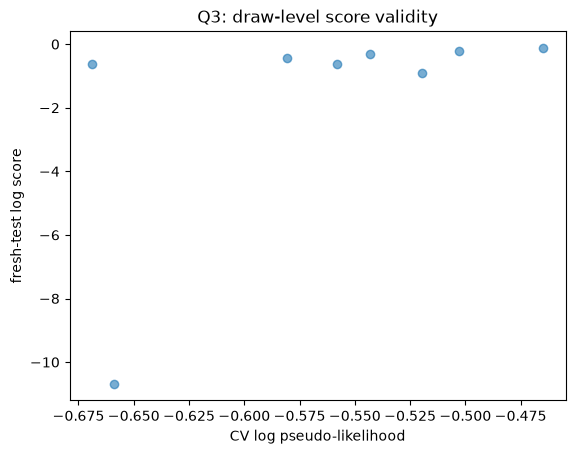

In [3]:
import matplotlib.pyplot as plt
plt.scatter(cv_scores, fresh_scores, alpha=0.6)
plt.xlabel('CV log pseudo-likelihood')
plt.ylabel('fresh-test log score')
plt.title('Q3: draw-level score validity')
plt.show()
# Add training and single-holdout scores, then repeat over data seeds.


## Conclusion from the executed starter run

**Status: not falsified; partial support.** The draw-level CV score had Spearman correlation 0.690 with fresh-test log score. That is consistent with useful ranking information, but the result comes from one split, and the fresh-test scores were much more variable than the CV scores. Repeated seeds and training/single-holdout controls are still required.